<a href="https://colab.research.google.com/github/adithyank757-ai/Old-to-new/blob/main/Another_copy_of_Wine_Quality_Classification_Using_KNN_and_PCA_by_Adithyan_k_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Wine Quality Classification Using KNN and PCA by Adithyan.k
#Roll no. 03
#s5AD

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load Wine Quality Dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# 1. Dataset shape (rows, columns)
print("=== Dataset Shape ===")
print(df.shape)

# 2. First 5 rows
print("\n=== First 5 Rows ===")
print(df.head())

# 3. Check for missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# 4. Check for duplicate rows
print("\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

=== Dataset Shape ===
(1599, 12)

=== First 5 Rows ===
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.

In [ ]:
# 1. Remove duplicate rows for clean modeling
df = df.drop_duplicates().reset_index(drop=True)

# 2. Define function to categorize quality
def categorize_quality(quality):
    if quality <= 5:
        return 0  # Low
    elif quality == 6:
        return 1  # Medium
    else:
        return 2  # High

# 3. Create target column
df['target'] = df['quality'].apply(categorize_quality)

# 4. Check class distribution
print("=== Cleaned Dataset Shape ===")
print(df.shape)

print("\n=== Target Class Distribution ===")
print(df['target'].value_counts().sort_index())
print("\nLabels key: 0 = Low (<=5), 1 = Medium (6), 2 = High (>=7)")

=== Cleaned Dataset Shape ===
(1359, 13)

=== Target Class Distribution ===
target
0    640
1    535
2    184
Name: count, dtype: int64

Labels key: 0 = Low (<=5), 1 = Medium (6), 2 = High (>=7)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  target                1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, 

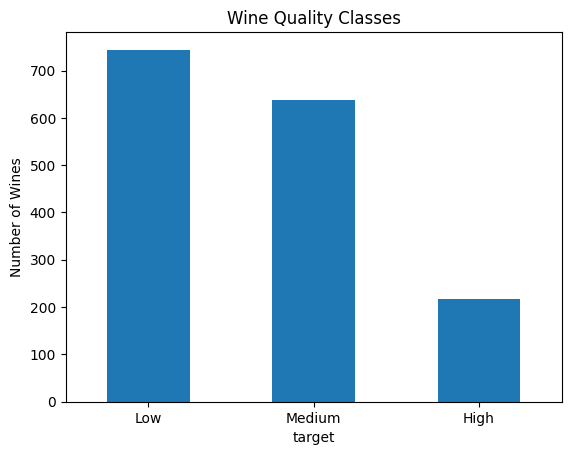

In [ ]:
import matplotlib.pyplot as plt

df.info()
df.describe()
print(df['quality'].value_counts().sort_index())

df['target'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1, 2], ['Low', 'Medium', 'High'], rotation=0)
plt.title('Wine Quality Classes')
plt.ylabel('Number of Wines')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df.drop(columns=['quality', 'target'])
y = df['target']

# 2. Train-Test Split (80% training, 20% testing with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardize features (Mean = 0, Variance = 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Print dataset split dimensions
print("=== Feature Scaling & Split Completed ===")
print(f"Training features shape : {X_train_scaled.shape}")
print(f"Testing features shape  : {X_test_scaled.shape}")

=== Feature Scaling & Split Completed ===
Training features shape : (1087, 11)
Testing features shape  : (272, 11)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Evaluate KNN across different values of K
k_values = [1, 3, 5, 7, 9]
knn_acc_orig = {}

print("=== Testing KNN Accuracy across K values (Without PCA) ===")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_acc_orig[k] = acc
    print(f"K = {k} --> Accuracy: {acc:.4f}")

# 2. Find best K
best_k_orig = max(knn_acc_orig, key=knn_acc_orig.get)
print(f"\nBest K without PCA: {best_k_orig} (Accuracy = {knn_acc_orig[best_k_orig]:.4f})")

# 3. Print Detailed Classification Report for Best K
best_knn_orig = KNeighborsClassifier(n_neighbors=best_k_orig)
best_knn_orig.fit(X_train_scaled, y_train)
y_pred_best_orig = best_knn_orig.predict(X_test_scaled)

print(f"\n=== Classification Report for Best K ({best_k_orig}) ===")
print(classification_report(y_test, y_pred_best_orig, target_names=['Low', 'Medium', 'High']))

=== Testing KNN Accuracy across K values (Without PCA) ===
K = 1 --> Accuracy: 0.5441
K = 3 --> Accuracy: 0.5404
K = 5 --> Accuracy: 0.6029
K = 7 --> Accuracy: 0.6140
K = 9 --> Accuracy: 0.6066

Best K without PCA: 7 (Accuracy = 0.6140)

=== Classification Report for Best K (7) ===
              precision    recall  f1-score   support

         Low       0.70      0.70      0.70       128
      Medium       0.53      0.56      0.55       107
        High       0.55      0.46      0.50        37

    accuracy                           0.61       272
   macro avg       0.59      0.57      0.58       272
weighted avg       0.61      0.61      0.61       272



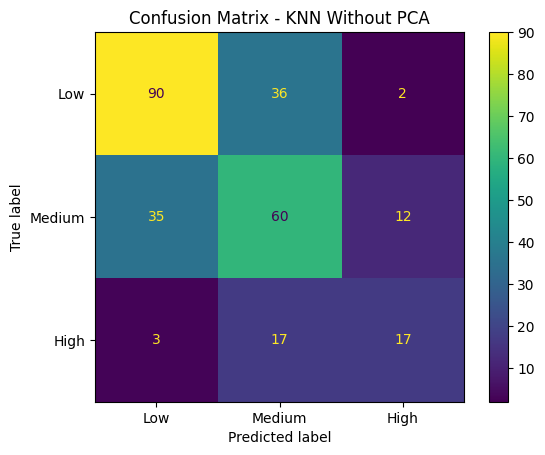

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_orig, display_labels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix - KNN Without PCA')
plt.show()

In [ ]:
pca_full = PCA().fit(X_train_scaled)
print(pca_full.explained_variance_ratio_)
print(np.cumsum(pca_full.explained_variance_ratio_))

[0.28443566 0.17197059 0.14143013 0.11365555 0.08555351 0.05910356
 0.05406742 0.0375262  0.03080229 0.01617311 0.00528198]
[0.28443566 0.45640625 0.59783639 0.71149193 0.79704544 0.856149
 0.91021642 0.94774262 0.97854491 0.99471802 1.        ]


In [ ]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to retain 90% of total variance
pca = PCA(n_components=0.90, random_state=42)

# 2. Fit PCA on training features and transform both train and test sets
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 3. Print variance analysis
print("=== PCA Dimensionality Reduction Summary ===")
print(f"Original number of features : {X_train_scaled.shape[1]}")
print(f"Reduced number of features  : {pca.n_components_}")
print(f"\nExplained Variance Ratio per component:")
for idx, var in enumerate(pca.explained_variance_ratio_):
    print(f"  Component {idx + 1}: {var * 100:.2f}%")

print(f"\nTotal Cumulative Explained Variance: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

=== PCA Dimensionality Reduction Summary ===
Original number of features : 11
Reduced number of features  : 7

Explained Variance Ratio per component:
  Component 1: 28.44%
  Component 2: 17.20%
  Component 3: 14.14%
  Component 4: 11.37%
  Component 5: 8.56%
  Component 6: 5.91%
  Component 7: 5.41%

Total Cumulative Explained Variance: 91.02%


In [ ]:
# 1. Evaluate KNN across different values of K on PCA features
knn_acc_pca = {}

print("=== Testing KNN Accuracy across K values (With PCA) ===")
for k in k_values:
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train)
    y_pred_pca = knn_pca.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred_pca)
    knn_acc_pca[k] = acc
    print(f"K = {k} --> Accuracy: {acc:.4f}")

# 2. Find best K with PCA
best_k_pca = max(knn_acc_pca, key=knn_acc_pca.get)
print(f"\nBest K with PCA: {best_k_pca} (Accuracy = {knn_acc_pca[best_k_pca]:.4f})")

# 3. Print Detailed Classification Report for Best K with PCA
best_knn_pca = KNeighborsClassifier(n_neighbors=best_k_pca)
best_knn_pca.fit(X_train_pca, y_train)
y_pred_best_pca = best_knn_pca.predict(X_test_pca)

print(f"\n=== Classification Report for Best K ({best_k_pca}) with PCA ===")
print(classification_report(y_test, y_pred_best_pca, target_names=['Low', 'Medium', 'High']))

=== Testing KNN Accuracy across K values (With PCA) ===
K = 1 --> Accuracy: 0.5662
K = 3 --> Accuracy: 0.5515
K = 5 --> Accuracy: 0.5919
K = 7 --> Accuracy: 0.5846
K = 9 --> Accuracy: 0.6029

Best K with PCA: 9 (Accuracy = 0.6029)

=== Classification Report for Best K (9) with PCA ===
              precision    recall  f1-score   support

         Low       0.67      0.74      0.71       128
      Medium       0.53      0.53      0.53       107
        High       0.52      0.32      0.40        37

    accuracy                           0.60       272
   macro avg       0.57      0.53      0.55       272
weighted avg       0.60      0.60      0.60       272



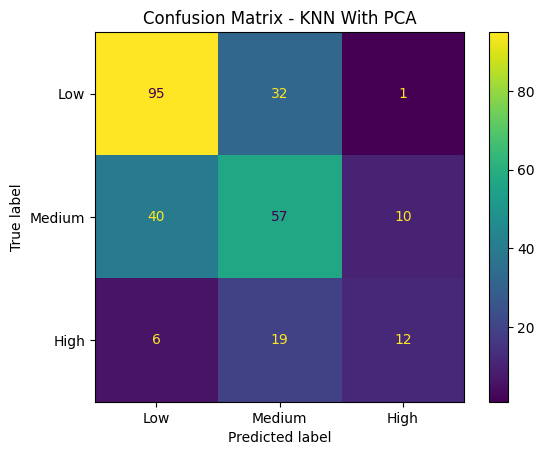

   K  KNN Without PCA  KNN With PCA
0  1         0.544118      0.566176
1  3         0.540441      0.551471
2  5         0.602941      0.591912
3  7         0.613971      0.584559
4  9         0.606618      0.602941
Accuracy difference: -0.011029411764705954


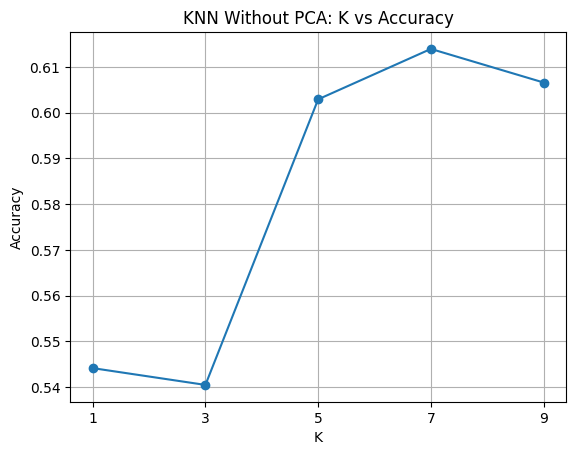

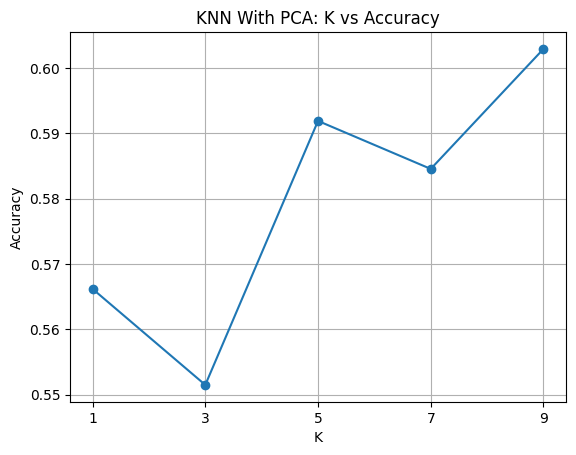

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_pca, display_labels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix - KNN With PCA')
plt.show()

# Per-K table and difference
results = pd.DataFrame({
    'K': k_values,
    'KNN Without PCA': [knn_acc_orig[k] for k in k_values],
    'KNN With PCA': [knn_acc_pca[k] for k in k_values]
})
print(results)

diff = knn_acc_pca[best_k_pca] - knn_acc_orig[best_k_orig]
print('Accuracy difference:', diff)

# Separate K vs accuracy plots
for name, d in [('Without PCA', knn_acc_orig), ('With PCA', knn_acc_pca)]:
    plt.plot(list(d.keys()), list(d.values()), marker='o')
    plt.title(f'KNN {name}: K vs Accuracy')
    plt.xlabel('K'); plt.ylabel('Accuracy')
    plt.xticks(k_values); plt.grid(True)
    plt.show()

fixed acidity           0.486605
citric acid             0.466008
density                 0.387585
sulphates               0.249790
chlorides               0.207677
residual sugar          0.134505
total sulfur dioxide    0.027757
free sulfur dioxide    -0.036512
alcohol                -0.107429
volatile acidity       -0.240972
pH                     -0.447775
Name: 0, dtype: float64


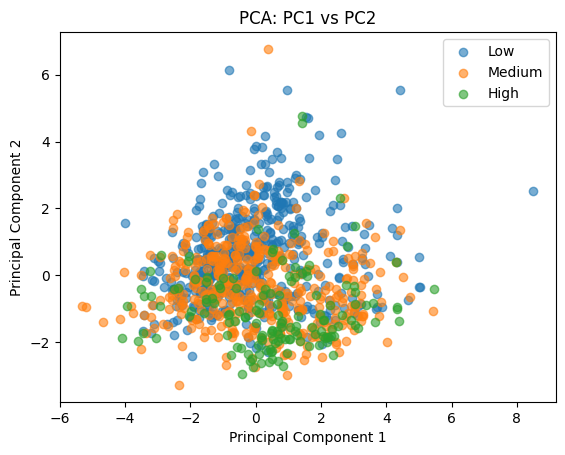

In [ ]:
loadings = pd.DataFrame(pca.components_, columns=X.columns)
print(loadings.iloc[0].sort_values(ascending=False))

labels = {0: 'Low', 1: 'Medium', 2: 'High'}
for c in [0, 1, 2]:
    m = (y_train == c).values
    plt.scatter(X_train_pca[m, 0], X_train_pca[m, 1], alpha=0.6, label=labels[c])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2')
plt.legend()
plt.show()

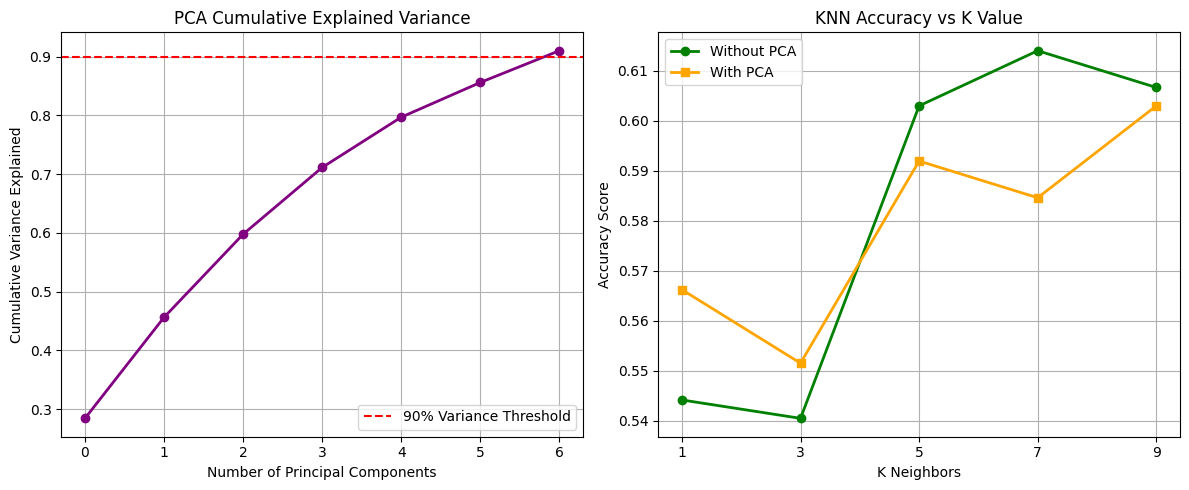


=== FINAL MODEL COMPARISON TABLE ===
              Metric KNN (Without PCA) KNN (With PCA)
        Best K Value                 7              9
       Feature Count                11              7
            Accuracy            0.6140         0.6029
Precision (Weighted)            0.6144         0.5957
   Recall (Weighted)            0.6140         0.6029
 F1-Score (Weighted)            0.6135         0.5954


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Setup Plot Figures
plt.figure(figsize=(12, 5))

# Plot A: PCA Cumulative Variance
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='purple', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.legend()
plt.grid(True)

# Plot B: Accuracy Comparison Across K Values
plt.subplot(1, 2, 2)
plt.plot(list(knn_acc_orig.keys()), list(knn_acc_orig.values()), marker='o', color='green', linewidth=2, label='Without PCA')
plt.plot(list(knn_acc_pca.keys()), list(knn_acc_pca.values()), marker='s', color='orange', linewidth=2, label='With PCA')
plt.title('KNN Accuracy vs K Value')
plt.xlabel('K Neighbors')
plt.ylabel('Accuracy Score')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Compute Metrics for Comparison Table
prec_orig = precision_score(y_test, y_pred_best_orig, average='weighted')
rec_orig = recall_score(y_test, y_pred_best_orig, average='weighted')
f1_orig = f1_score(y_test, y_pred_best_orig, average='weighted')

prec_pca = precision_score(y_test, y_pred_best_pca, average='weighted')
rec_pca = recall_score(y_test, y_pred_best_pca, average='weighted')
f1_pca = f1_score(y_test, y_pred_best_pca, average='weighted')

# 3. Display Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Best K Value', 'Feature Count', 'Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'KNN (Without PCA)': [best_k_orig, X_train_scaled.shape[1], f"{knn_acc_orig[best_k_orig]:.4f}", f"{prec_orig:.4f}", f"{rec_orig:.4f}", f"{f1_orig:.4f}"],
    'KNN (With PCA)': [best_k_pca, pca.n_components_, f"{knn_acc_pca[best_k_pca]:.4f}", f"{prec_pca:.4f}", f"{rec_pca:.4f}", f"{f1_pca:.4f}"]
})

print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))